# Phase 4 — GARCH(1,1) volatility-adjusted thresholds

Replace the fixed ±2 entry band with

`entry_t = ENTRY_Z × clip(σ̂_t / σ̄, SCALE_MIN, SCALE_MAX)`

where σ̂_t is the one-step-ahead GARCH(1,1) forecast of spread volatility and σ̄ is its average over the fit window. When vol is high the bands widen, and when it is calm they tighten. Every forecast uses data up to bar t only (daily walk-forward refit + hand-written variance recursion).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))   # make /src importable

import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
%matplotlib inline

In [2]:
from data_pipeline import load_universe, split_formation_trading
from cointegration import FORMATION_DAYS, screen_pairs, select_pairs_for_trading

universe = load_universe()                      # cached parquet in /data; refresh=True to re-download
formation = {k: split_formation_trading(v, FORMATION_DAYS)[0] for k, v in universe.items()}
phase1 = screen_pairs(formation)
selected, used_fallback = select_pairs_for_trading(phase1)
PAIR = selected[0]
prices = universe[PAIR]
trade_start = split_formation_trading(prices, FORMATION_DAYS)[1].index[0]
print(f"Trading pair: {PAIR}   fallback used: {used_fallback}   trading period starts {trade_start}")

Trading pair: SBIN/BANKBARODA   fallback used: True   trading period starts 2026-07-30 09:15:00+05:30


In [3]:
import garch_thresholds as gt
from strategy import build_signals
print({k: getattr(gt, k) for k in ["GARCH_WINDOW_DAYS", "RETURN_SCALE", "DROP_OVERNIGHT_RETURNS",
                                    "MEAN_MODEL", "ERROR_DIST", "SCALE_MIN", "SCALE_MAX"]})
sig = build_signals(prices, trade_start=trade_start)

{'GARCH_WINDOW_DAYS': 15, 'RETURN_SCALE': 10000, 'DROP_OVERNIGHT_RETURNS': True, 'MEAN_MODEL': 'Constant', 'ERROR_DIST': 'normal', 'SCALE_MIN': 0.5, 'SCALE_MAX': 2.0}


## 1. Stationarity check on spread returns (ADF first, as before)
GARCH models the variance of a **stationary** series. The spread *level* may not be stationary (Phase 1), but its first difference should be. Same ADF pattern: H0 = unit root.

In [4]:
from cointegration import adf_test
r_trade = gt.spread_returns(prices[prices.index >= trade_start], sig["beta"].iloc[0])
lvl = prices[prices.index >= trade_start]
spread_level = lvl.iloc[:, 0] - sig["beta"].iloc[0] * lvl.iloc[:, 1]
pd.DataFrame({"spread level": adf_test(spread_level), "spread returns (bps)": adf_test(r_trade)}).T

,adf_stat,p_value,used_lag,n_obs,crit_1%,crit_5%,reject_null
spread level,-1.196521,0.675091,14,3185,-3.432405,-2.862448,False
spread returns (bps),-17.392303,0.0,13,3142,-3.432433,-2.86246,True


## 2. One GARCH(1,1) fit on the trading period (for inspection only)
This single fit uses the whole trading period, so it is **not** used for signals (that would be lookahead). It is here so we can read a standard `arch` summary and check that alpha, beta > 0 and alpha + beta < 1.

In [5]:
full_fit = gt.fit_garch(r_trade, p=1, q=1)
arch_fit = gt.fit_garch(r_trade, p=1, q=0)
print(full_fit.summary())
print(f"\nAIC  ARCH(1) = {arch_fit.aic:.1f}   GARCH(1,1) = {full_fit.aic:.1f}   (lower is better)")

                     Constant Mean - GARCH Model Results                      
Dep. Variable:         spread_ret_bps   R-squared:                       0.000
Mean Model:             Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -12010.2
Distribution:                  Normal   AIC:                           24028.3
Method:            Maximum Likelihood   BIC:                           24052.5
                                        No. Observations:                 3156
Date:                Thu, Oct 01 2026   Df Residuals:                     3155
Time:                        08:35:48   Df Model:                            1
                               Mean Model                               
                 coef    std err          t      P>|t|  95.0% Conf. Int.
------------------------------------------------------------------------
mu            -0.1507      0.367     -0.410      0.682 [ -0.871,  0.56

## 3. Rolling (walk-forward) GARCH forecasts

In [6]:
vol, params = gt.rolling_garch(prices, sig)
print(f"{len(params)} daily refits, {(~params['converged']).sum()} non-converged (previous params reused)")
params.round(3).head()

44 daily refits, 0 non-converged (previous params reused)


,arch_omega,arch_alpha,garch_omega,garch_alpha,garch_beta,persistence,arch_aic,garch_aic,converged
date,,,,,,,,,
2026-07-30 00:00:00+05:30,112.698,0.215,112.700,0.215,0.000,0.215,8605.395,8607.395,True
2026-07-31 00:00:00+05:30,114.708,0.208,114.169,0.208,0.004,0.212,8619.325,8621.324,True
2026-08-03 00:00:00+05:30,103.843,0.219,91.984,0.214,0.095,0.308,8519.308,8520.828,True
2026-08-04 00:00:00+05:30,122.868,0.208,37.492,0.165,0.607,0.772,8664.447,8662.908,True
2026-08-05 00:00:00+05:30,109.606,0.195,67.615,0.187,0.322,0.508,8503.918,8500.930,True


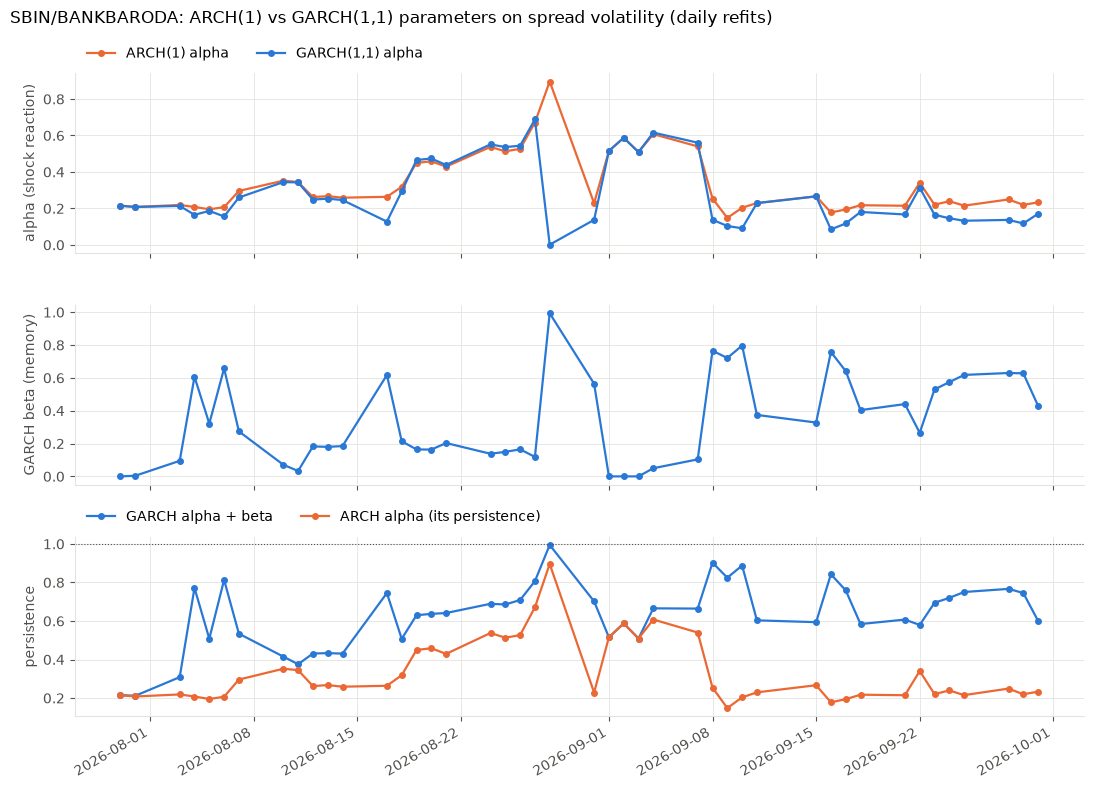

In [7]:
gt.plot_parameter_evolution(params, f"{PAIR}: ARCH(1) vs GARCH(1,1) parameters on spread volatility (daily refits)"); plt.show()

**Reading the parameter plot**
- ARCH alpha is usually higher than GARCH alpha. With no beta term, ARCH(1) has to load everything onto the latest shock to capture volatility clustering.
- GARCH persistence (alpha + beta) close to 1 means vol shocks to the spread are long-lived, so the adaptive threshold stays wide for a while after a shock. Lower persistence means shocks fade within a few bars.
- Large day-to-day jumps in the parameters are a sign of the short sample (15-day windows). Treat them as estimation noise, not regime changes.

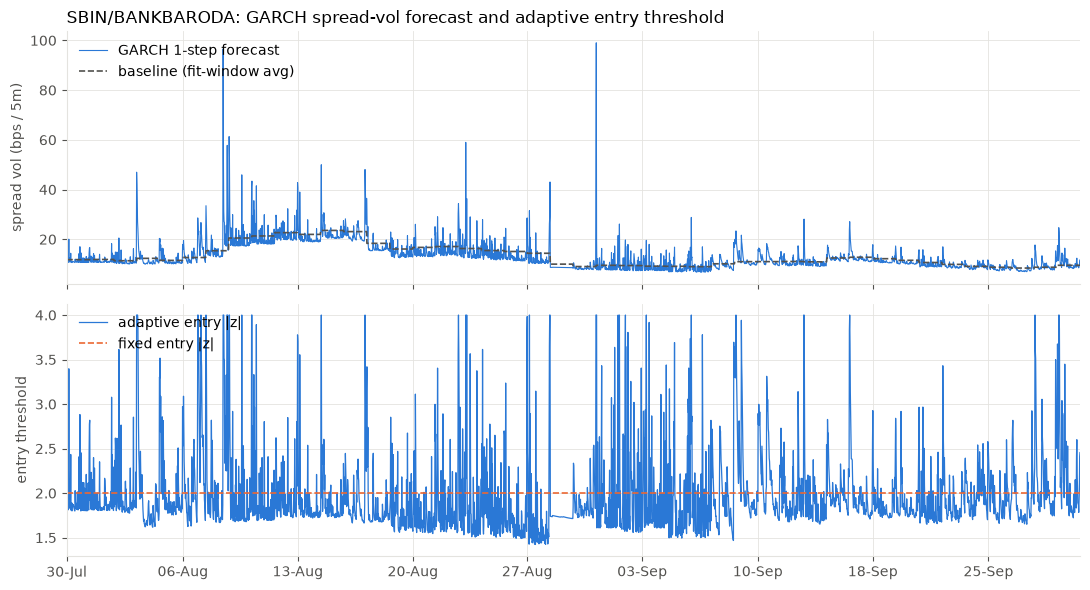

,count,mean,std,min,25%,50%,75%,max
vol ratio (clipped),3200.0,0.988332,0.224847,0.711846,0.8656,0.914567,1.025017,2.0


In [8]:
gt.plot_vol_and_thresholds(vol, title=f"{PAIR}: GARCH spread-vol forecast and adaptive entry threshold"); plt.show()
vol["vol_ratio"].describe().to_frame("vol ratio (clipped)").T

## 4. Three-way comparison (all after costs)
1. **Fixed threshold**: Phase 2/3 strategy, ±2 entry, exit at 0
2. **GARCH-adjusted threshold**: same engine, entry/exit scaled by the vol ratio
3. **Buy & hold**: 50/50 long both stocks over the trading period, charged at delivery rates

In [9]:
from strategy import run_backtest, buy_and_hold
from costs import IndianEquityCostModel
from backtest_report import comparison_table, format_table, plot_equity, plot_drawdown, plot_zscore_signals

cm = IndianEquityCostModel()
s = sig.loc[vol.index]
entry_t, exit_t = gt.adaptive_thresholds(vol)
fixed = run_backtest(s, cost_model=cm, label="fixed threshold")
garch = run_backtest(s, entry_t, exit_t, cost_model=cm, label="GARCH threshold")
bh = buy_and_hold(s[s.columns[:2]], cost_model=cm, label="buy & hold")
format_table(comparison_table([fixed, garch, bh]))

,fixed threshold,GARCH threshold,buy & hold
Total return,-3.70%,-4.11%,-5.26%
Annualised return,-19.44%,-21.37%,-26.63%
Annualised excess return,-25.94%,-27.87%,-33.13%
Annualised volatility,4.51%,4.57%,16.92%
Sharpe ratio,-6.17,-6.61,-2.12
Max drawdown,-4.54%,-4.93%,-12.72%
Number of trades,59,57,1
Win rate,42.37%,40.35%,0.00%
Avg holding (bars),29.78,30.56,3199.00
Avg holding (minutes),148.90,152.81,15995.00


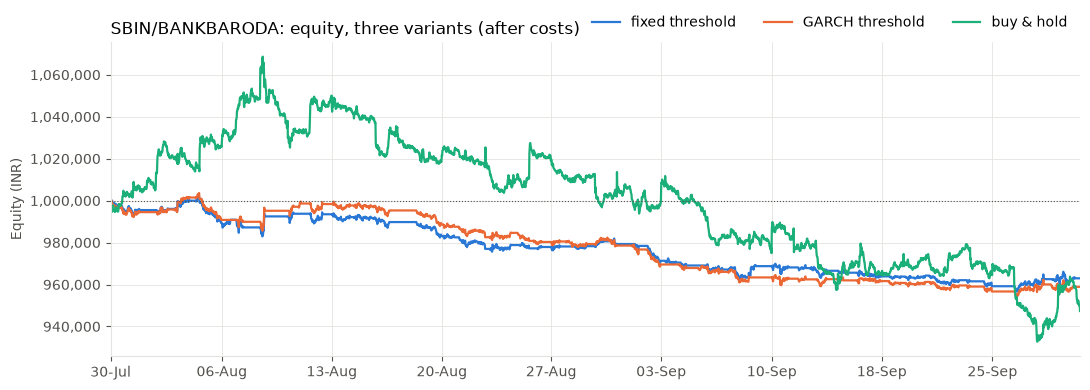

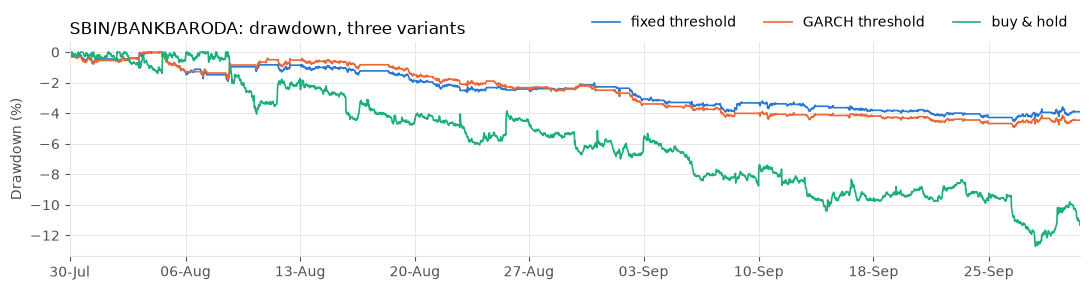

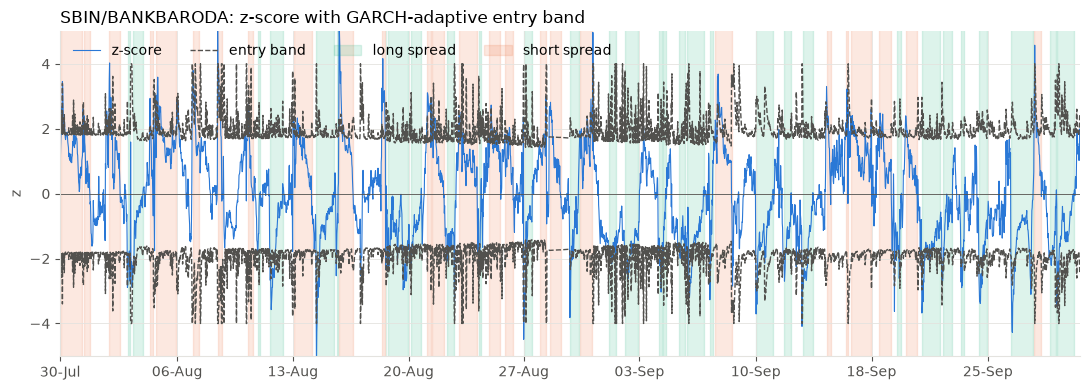

In [10]:
plot_equity([fixed, garch, bh], f"{PAIR}: equity, three variants (after costs)"); plt.show()
plot_drawdown([fixed, garch, bh], f"{PAIR}: drawdown, three variants"); plt.show()
plot_zscore_signals(garch, f"{PAIR}: z-score with GARCH-adaptive entry band"); plt.show()

## 5. Same comparison for every candidate pair
A single pair over ~40 days is anecdotal. Running all candidates shows whether the GARCH adjustment helps *consistently* or just on one sample.

In [11]:
rows = []
for k, px in universe.items():
    ts = split_formation_trading(px, FORMATION_DAYS)[1].index[0]
    sg = build_signals(px, trade_start=ts)
    v, _ = gt.rolling_garch(px, sg)
    sg = sg.loc[v.index]
    e, x = gt.adaptive_thresholds(v)
    for res in (run_backtest(sg, cost_model=cm, label="fixed"),
                run_backtest(sg, e, x, cost_model=cm, label="GARCH")):
        m = comparison_table([res])[res.label]
        rows.append({"pair": k, "variant": res.label, "Total return": m["Total return"],
                     "Sharpe": m["Sharpe ratio"], "Max DD": m["Max drawdown"], "Trades": m["Number of trades"]})
pd.DataFrame(rows).set_index(["pair", "variant"]).style.format(
    {"Total return": "{:.2%}", "Sharpe": "{:.2f}", "Max DD": "{:.2%}", "Trades": "{:.0f}"})